## Volatility regime detection with Hidden Markov Model ##

### Appendix - What if all vols? ###


Paulo Yoshio Kuga


**Abstract**

In the previous notebook, we used log parkinson as a way to adapt a HMM as representative of our volatility dynamics. But what if we could compare all volatilties?


In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import bandeirante as bd
import numpy as np

from hmmlearn.hmm import GaussianHMM

import yfinance as yf

from datetime import datetime

Again, we use our yfinance data and calculates all the volatilities, using a window of 21 days. 

In [2]:
start_date = datetime(2016,1,1)
end_date = datetime.today()

ticker = "^BVSP"

dataset = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    interval="1d"
    ).droplevel(axis=1,level=1)

w = 21 #general volatility window

dataset["returns"] = dataset["Close"].pct_change().add(1).apply(np.log).dropna()
dataset["vol_std"] = np.log(dataset.returns.rolling(w).std().dropna())

dataset["vol_PK"] = np.log(bd.parkinson(dataset,w,max_str="High",min_str="Low"))
dataset["vol_GK"] = np.log(bd.garman_klass(dataset,w,max_str="High",min_str="Low",close_str="Close",open_str="Open"))
dataset["vol_RS"] = np.log(bd.rogers_satchell(dataset,w,max_str="High",min_str="Low",close_str="Close",open_str="Open"))
dataset["vol_YZ"] = np.log(bd.yang_zhang(dataset,w,max_str="High",min_str="Low",close_str="Close",open_str="Open"))

dataset.dropna(inplace=True) #to assure consistency along the dataset

[*********************100%***********************]  1 of 1 completed


We can plot the log-returns and the two types of volatility. It is possible to notice that, usually, Parkinson volatility tends to be more conservative along the time. It is known that statistical standard deviation volatility tends to superestimate volatility true value.

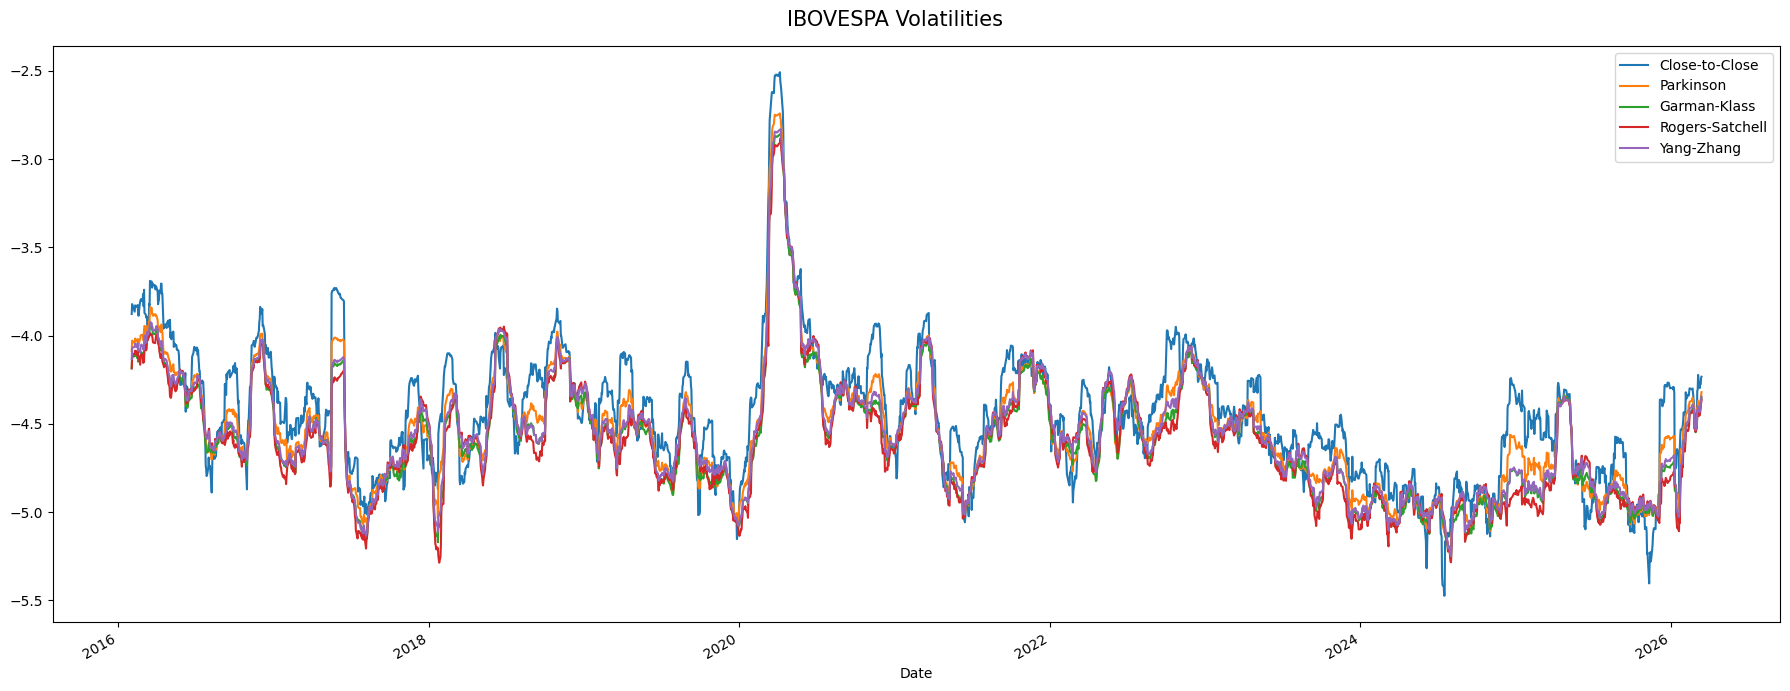

In [3]:
fig,axs = plt.subplots(1,1, figsize=(18,7),sharex=True)

dataset["vol_std"].plot(ax=axs)
dataset["vol_PK"].plot(ax=axs)
dataset["vol_GK"].plot(ax=axs)
dataset["vol_RS"].plot(ax=axs)
dataset["vol_YZ"].plot(ax=axs)

fig.suptitle("IBOVESPA Volatilities",fontsize=15)

axs.legend(["Close-to-Close","Parkinson","Garman-Klass","Rogers-Satchell","Yang-Zhang"])


fig.tight_layout()

As before, we set our models.

In [4]:
def hmm_model_generator(
        vol, 
        n = 3,
        anti_stall = 1,
        train_test_percentual = 0.95,
        random_state = 20000728
        ):

    X = vol.to_numpy().reshape(-1,1)*anti_stall

    series_length,_ = X.shape  

    cut_value = int(np.ceil((series_length*train_test_percentual)))

    X_train= X[:cut_value]

    hmm_model = GaussianHMM(n_components=n,covariance_type="full",random_state=random_state)

    hmm_model.fit(X_train)

    return hmm_model,X, cut_value


def state_as_stationary(hmm_model,n_states):
    stationary = hmm_model.get_stationary_distribution()

    states_order = dict(
    zip(
        np.argsort(stationary)[::-1],np.array(range(0,n_states))
        )
    )
    order_function = np.vectorize(states_order.get)

    return order_function

n_states = 3

def train_hmm_and_plot(dataset,series_name,state_name,ax,pallette="YlOrRd",states=3):
    
    hmm_model_std, X_std, cut_value, = hmm_model_generator(dataset[series_name])
    prediction_std = state_as_stationary(hmm_model_std,states)(hmm_model_std.predict(X_std))
    dataset[state_name] = prediction_std

    dataset[series_name].plot(ax=ax)
    bd.add_state_background(dataset,series_name,state_name,n=states,ax=ax,chosenPallete=pallette)
    ax.axvline(x=dataset.index[cut_value], color='r', linestyle='dashed', linewidth=2)

We set our number of states as 3 for all vols. These 3 states could be characterized as levels of volatility intensity and the type of regime, such as "low-vol", "mid-vol" and "high-vol". We predict the states for the entire series, and when predicting, re-ordering the states to adhere our convention.


After this, using add_state_background function in Bandeirante, we can plot our states as coloured backgrounds:

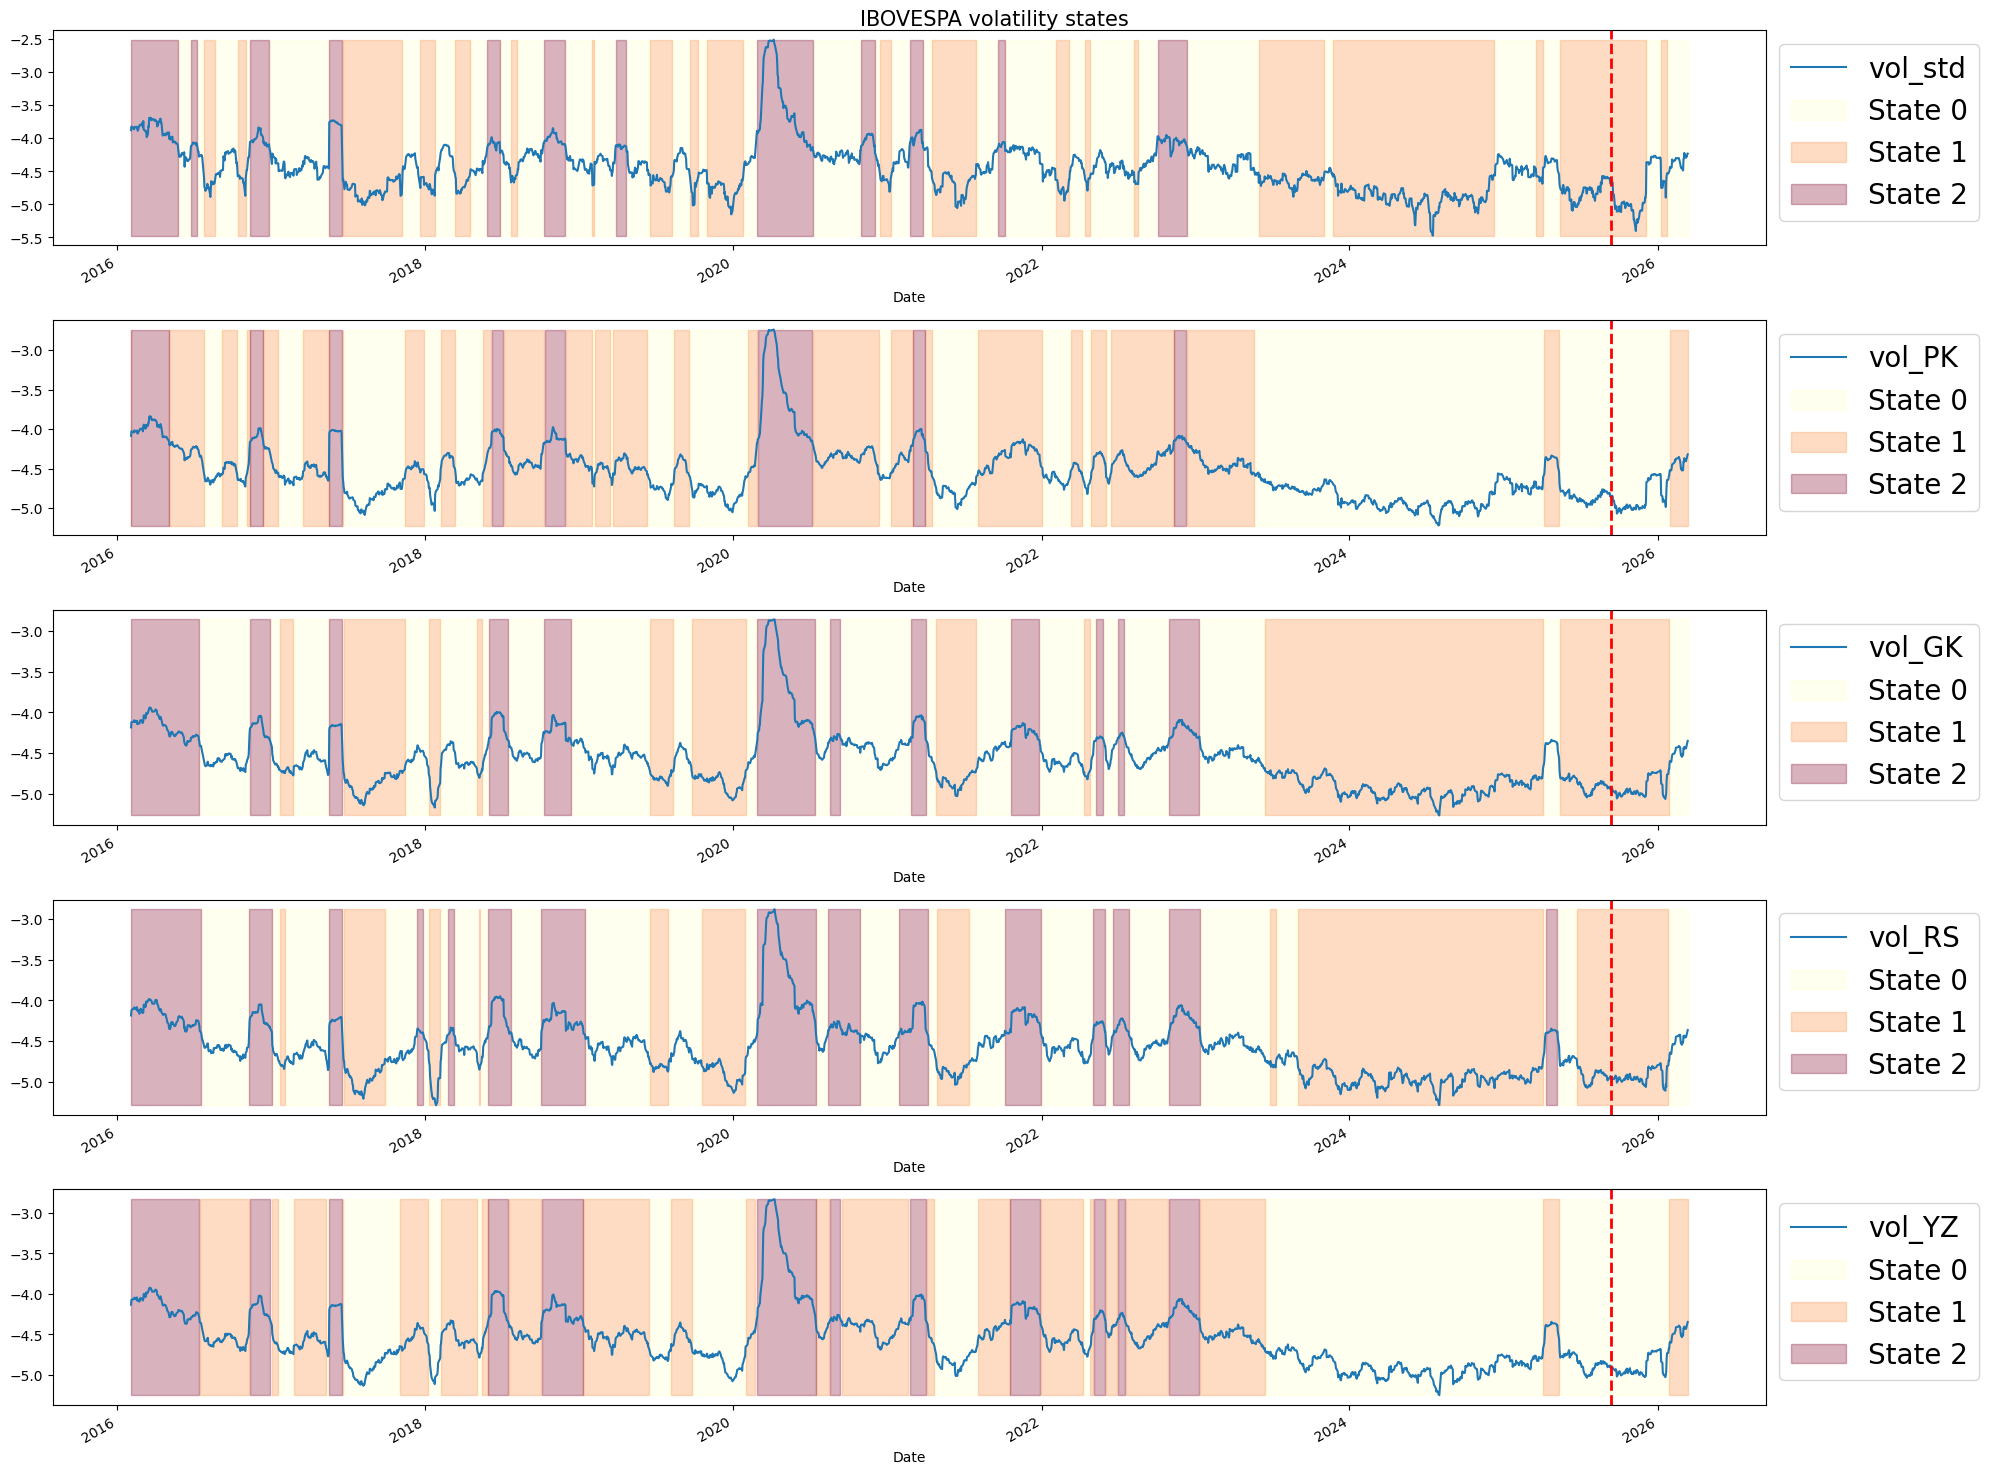

In [5]:
fig,axs = plt.subplots(5,1,figsize=(20,15))

train_hmm_and_plot(dataset,"vol_std","state_std",axs[0])
train_hmm_and_plot(dataset,"vol_PK","state_PK",axs[1])
train_hmm_and_plot(dataset,"vol_GK","state_GK",axs[2])
train_hmm_and_plot(dataset,"vol_RS","state_RS",axs[3])
train_hmm_and_plot(dataset,"vol_YZ","state_YZ",axs[4])



fig.suptitle("IBOVESPA volatility states",fontsize=15)
plt.tight_layout(pad=1.1)

It is possible to observe that YZ vol appears to be the more reasonable model. Peaks are well defined by state 3 and riskier vols are defined by state 2. Moreover it is possible to notice the state 0 would represent the normal vol levels. 

In [8]:
np.exp(dataset.vol_YZ.iloc[-1])

np.float64(0.012963576569850248)